In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/BreastCancer.csv"

df = pd.read_csv(url)

df.head()

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0


In [2]:
df.isna().sum()

,0
Id,0
Cl.thickness,0
Cell.size,0
Cell.shape,0
Marg.adhesion,0
Epith.c.size,0
Bare.nuclei,16
Bl.cromatin,0
Normal.nucleoli,0
Mitoses,0


In [3]:
df['Bare.nuclei'] = df['Bare.nuclei'].fillna(df['Bare.nuclei'].median())

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
#Gini
cart_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)
model1=cart_model.fit(X_train, y_train)
y_pred = cart_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9285714285714286


In [8]:
param_grid = {
    'max_depth': [2, 3, 5, 7, 10, None],
    'min_samples_split': [2, 4, 6, 8, 10]
}

In [9]:
grid_search = GridSearchCV(
    estimator=cart_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


In [26]:
model2=grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 3, 'min_samples_split': 2}


In [11]:
best_cart = grid_search.best_estimator_


In [12]:
y_pred = best_cart.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy:", accuracy)


Test Accuracy: 0.9285714285714286


In [13]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        95
           1       0.87      0.91      0.89        45

    accuracy                           0.93       140
   macro avg       0.91      0.92      0.92       140
weighted avg       0.93      0.93      0.93       140



In [14]:
#ID3
id3_model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

In [15]:
best_id3 = grid_search.best_estimator_

In [16]:
y_pred2 = best_id3.predict(X_test)

In [17]:
accuracy2= accuracy_score(y_test, y_pred2)
accuracy

0.9285714285714286

In [18]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred2))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        95
           1       0.87      0.91      0.89        45

    accuracy                           0.93       140
   macro avg       0.91      0.92      0.92       140
weighted avg       0.93      0.93      0.93       140



In [19]:
from sklearn.tree import plot_tree
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.decomposition import PCA

In [20]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

cart_2d = DecisionTreeClassifier(
    criterion='gini',
    max_depth=cart_model.max_depth,
    min_samples_split=cart_model.min_samples_split,
    random_state=42
)

id3_2d = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=id3_model.max_depth,
    min_samples_split=id3_model.min_samples_split,
    random_state=42
)

cart_2d.fit(X_train_pca, y_train_pca)
id3_2d.fit(X_train_pca, y_train_pca)


DecisionTreeClassifier(criterion='entropy', random_state=42)

Grid size: 35,306,631 points


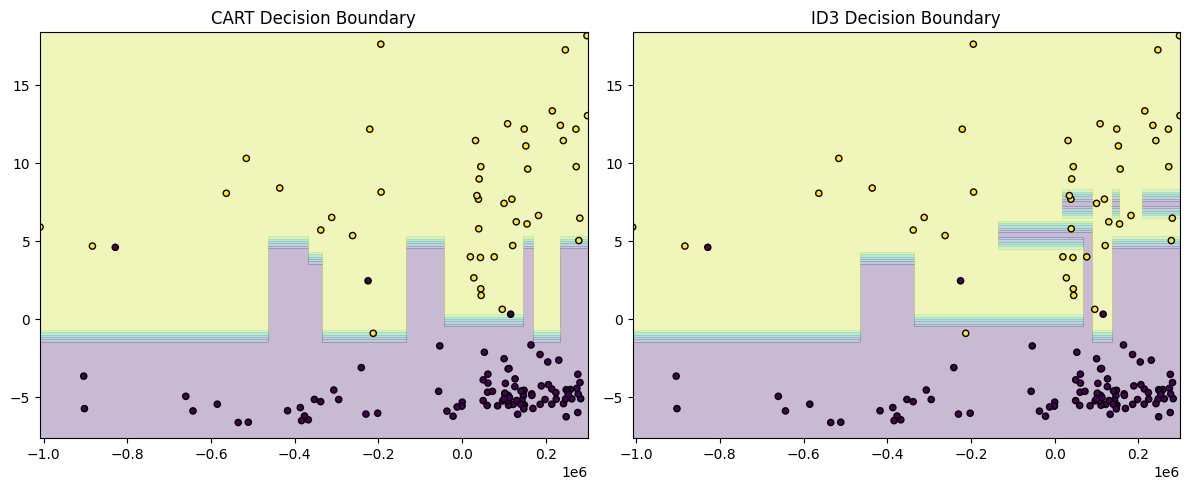

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import gc

step = 1.0  # very coarse, change to 0.5 if it looks too blocky

x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1

x_vals = np.arange(x_min, x_max, step, dtype=np.float32)
y_vals = np.arange(y_min, y_max, step, dtype=np.float32)

print(f"Grid size: {len(x_vals) * len(y_vals):,} points")  # check before proceeding

xx, yy = np.meshgrid(x_vals, y_vals)
del x_vals, y_vals
gc.collect()

grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

# Predict one model at a time, plot immediately, then free
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, title in zip(axes,
                              [cart_2d, id3_2d],
                              ["CART Decision Boundary", "ID3 Decision Boundary"]):
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
               c=y_test_pca, edgecolor='k', s=20)
    ax.set_title(title)
    del Z
    gc.collect()

del grid, xx, yy
gc.collect()

plt.tight_layout()
plt.show()

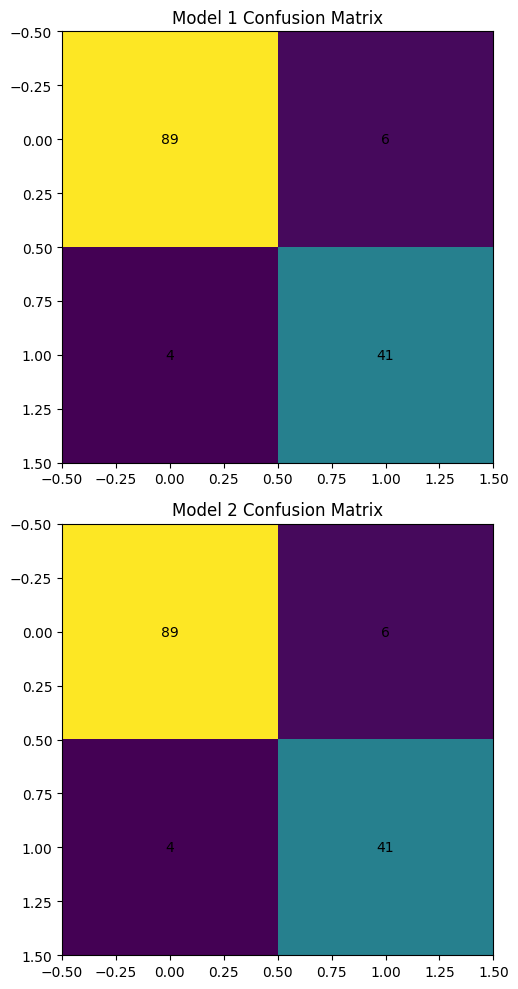

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test, y_pred)
cm2 = confusion_matrix(y_test, y_pred2)

fig, ax = plt.subplots(2, 1, figsize=(6, 10))

ax[0].imshow(cm1)
ax[0].set_title("Model 1 Confusion Matrix")
for i in range(cm1.shape[0]):
    for j in range(cm1.shape[1]):
        ax[0].text(j, i, cm1[i, j], ha='center', va='center')

ax[1].imshow(cm2)
ax[1].set_title("Model 2 Confusion Matrix")
for i in range(cm2.shape[0]):
    for j in range(cm2.shape[1]):
        ax[1].text(j, i, cm2[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

In [27]:
y_pred_proba_model1 = model1.predict_proba(X_test)[:, 1]
y_pred_proba_model2 = model2.predict_proba(X_test)[:, 1]

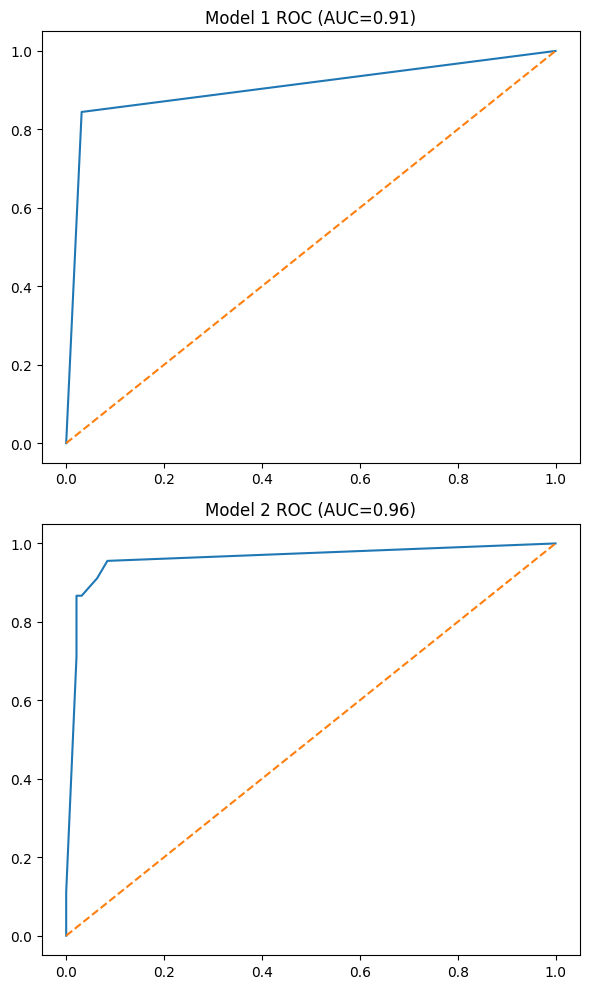

In [28]:

from sklearn.metrics import roc_curve, auc
fpr1, tpr1, _ = roc_curve(y_test, y_pred_proba_model1)
fpr2, tpr2, _ = roc_curve(y_test, y_pred_proba_model2)

auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)

fig, ax = plt.subplots(2, 1, figsize=(6, 10))

ax[0].plot(fpr1, tpr1)
ax[0].plot([0, 1], [0, 1], linestyle='--')
ax[0].set_title(f"Model 1 ROC (AUC={auc1:.2f})")

ax[1].plot(fpr2, tpr2)
ax[1].plot([0, 1], [0, 1], linestyle='--')
ax[1].set_title(f"Model 2 ROC (AUC={auc2:.2f})")

plt.tight_layout()
plt.show()

In [30]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

df_metrics = pd.DataFrame({
    "Metric": metrics,
    "Model_1": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred_proba_model1)
    ],
    "Model_2": [
        accuracy_score(y_test, y_pred2),
        precision_score(y_test, y_pred2),
        recall_score(y_test, y_pred2),
        f1_score(y_test, y_pred2),
        roc_auc_score(y_test,y_pred_proba_model1)
    ]
})

df_metrics

,Metric,Model_1,Model_2
0,Accuracy,0.928571,0.928571
1,Precision,0.926829,0.872340
2,Recall,0.844444,0.911111
3,F1,0.883721,0.891304
4,AUC,0.906433,0.906433


In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}


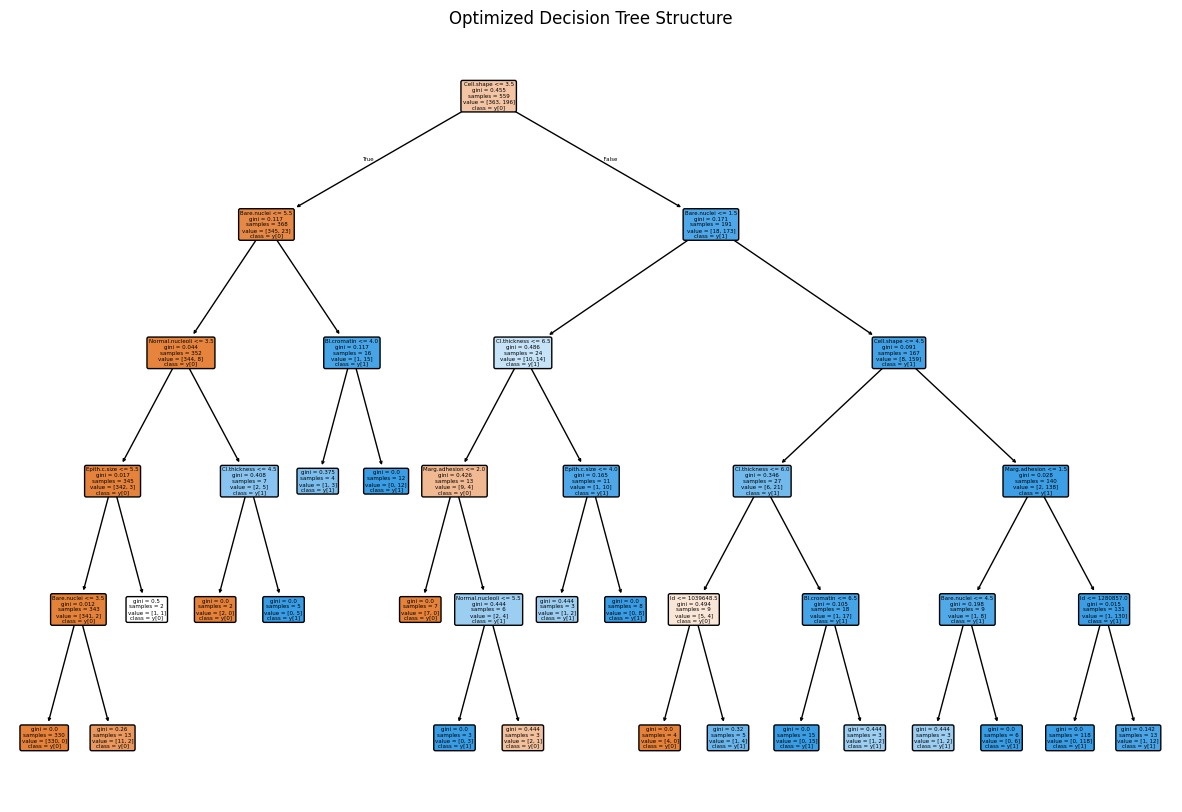

In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

plot_tree(
    best_model,          # your optimized Decision Tree model
    filled=True,
    feature_names=X.columns,
    class_names=True,
    rounded=True
)

plt.title("Optimized Decision Tree Structure")
plt.show()